# Modelado — Predicción de reingreso hospitalario 

En este notebook se entrenan y comparan distintos modelos de clasificación para predecir el reingreso hospitalario dentro de los 30 días posteriores al alta.

El objetivo de esta fase es identificar qué algoritmo ofrece mejor capacidad discriminativa sobre el dataset preprocesado, sentando la base para el análisis en profundidad del notebook de evaluación.

**Modelos evaluados:**
- Regresión Logística — baseline lineal interpretable
- Random Forest — conjunto de árboles, captura relaciones no lineales
- XGBoost — gradient boosting, robusto con datos tabulares
- LightGBM — gradient boosting optimizado en velocidad y memoria

**Métricas principales:** ROC-AUC y Recall, dado que en contexto clínico interesa detectar el máximo número de pacientes en riesgo real.

## 1. Imports y configuración

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

from src.models.train import (
    load_data, split_data, get_models,
    run_all_models, cross_validate_model, tune_model, get_metrics
)
from src.evaluation.evaluate import (
    plot_confusion_matrix, get_classification_report
)

## 2. Carga del dataset

In [2]:
X, y = load_data()

print(f"Dataset: {X.shape[0]:,} registros — {X.shape[1]} variables predictoras")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nProporción positivos (readmisión): {y.mean():.1%}")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342
Dataset: 315,982 registros — 54 variables predictoras

Distribución de la variable objetivo:
readmission_30_days
0    208032
1    107950
Name: count, dtype: int64

Proporción positivos (readmisión): 34.2%


### Nota sobre el desbalanceo de clases y estrategia de balanceo

La variable objetivo presenta una distribución de 65.8% negativo / 34.2% positivo. Este desbalanceo es moderado pero, con el umbral por defecto de 0.5, los modelos tienden a priorizar la clase mayoritaria y producen un recall muy bajo sobre la clase de interés clínico (readmisión).

**Estrategia adoptada:** todos los modelos se entrenan con `class_weight='balanced'` (o `scale_pos_weight` en XGBoost), lo que ajusta los pesos de las clases inversamente proporcional a su frecuencia. Esto aumenta el recall a costa de algo de precisión, que es el trade-off deseable en un contexto de screening clínico donde el coste de los falsos negativos (pacientes en riesgo no detectados) es mayor que el de los falsos positivos.

## 3. División en entrenamiento y test

In [3]:
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean():.1%} positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean():.1%} positivos)")

Train: 252,785 registros (34.2% positivos)
Test:  63,197 registros (34.2% positivos)


## 4. Entrenamiento y comparación de modelos

Los modelos se ordenan por ROC-AUC con Average Precision (PR-AUC) como criterio de desempate. ROC-AUC resume cómo de bien separa el modelo los reingresos de los que no reingresan; Average Precision complementa esa medida centrándose en la clase positiva, lo que es más útil cuando hay desbalanceo. Ambas métricas se evalúan sobre el conjunto de test (20% de los datos, nunca visto durante el entrenamiento).

In [4]:
results_df, trained_models = run_all_models(X_train, X_test, y_train, y_test)
results_df

Training models...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision,Train time (s)
Model,,,,,,,
LightGBM,0.6131,0.4506,0.6051,0.5166,0.6568,0.5057,1.5
XGBoost,0.6121,0.4497,0.6048,0.5158,0.6567,0.5061,3.1
Logistic Regression,0.6118,0.4450,0.5513,0.4925,0.6339,0.4672,1.3
Random Forest,0.6584,0.5000,0.2694,0.3502,0.6221,0.4646,29.4


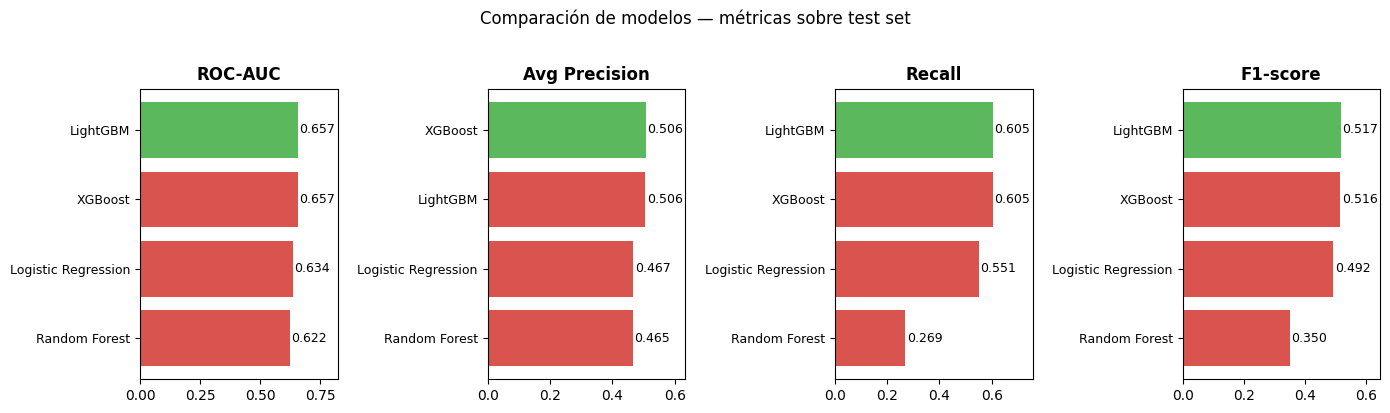

In [5]:
# Gráfico comparativo de modelos en las métricas clave
metrics_to_plot = ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].sort_values()
    colors = ["#d9534f" if m != results_df[metric].idxmax() else "#5cb85c" for m in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlim(0, max(values.values) * 1.25)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Comparación de modelos — métricas sobre test set", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Justificación de la selección del modelo

La elección del modelo final combina tres criterios: rendimiento (ROC-AUC), relevancia clínica (Recall) e interpretabilidad (soporte SHAP).

**Regresión Logística** queda como baseline: su AUC de 0.634 es el más bajo y su supuesto de linealidad no captura bien las interacciones entre variables clínicas.

**Random Forest** se descarta por un Recall de 0.27 — detecta solo 1 de cada 4 reingresos reales, lo que es clínicamente inaceptable en un sistema de screening.

**XGBoost y LightGBM** son prácticamente equivalentes en rendimiento (AUC 0.6567 vs 0.6568). Se elige **LightGBM** por ser 2.5× más rápido en entrenamiento, lo que es relevante en la búsqueda de hiperparámetros sobre 250k filas, y por su integración nativa con SHAP `TreeExplainer`.

El análisis en profundidad del modelo seleccionado se realiza en `04_evaluation.ipynb`.

## 5. Validación cruzada del mejor modelo

Se aplica validación cruzada estratificada de 5 folds **solo sobre el conjunto de entrenamiento** para estimar la estabilidad del modelo sin tocar el test set.

El AUC medio del CV es ligeramente inferior al del modelo final porque cada fold entrena con el 80% del train (~202k filas) frente a las ~253k del modelo completo. Esto es normal y no indica ningún problema — el CV sirve para detectar varianza entre folds, no para medir el rendimiento definitivo.

In [6]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"ROC-AUC (test): {results_df.loc[best_model_name, 'ROC-AUC']}")

# CV sobre X_train/y_train únicamente — el test set no debe participar
# en la estimación de rendimiento para evitar data leakage
cv_results = cross_validate_model(best_model, X_train, y_train, cv=5)
print(f"ROC-AUC (CV 5-fold sobre train): {cv_results['cv_roc_auc_mean']} ± {cv_results['cv_roc_auc_std']}")

Mejor modelo: LightGBM
ROC-AUC (test): 0.6568
ROC-AUC (CV 5-fold sobre train): 0.6566 ± 0.0034


## 6. Optimización de hiperparámetros

Los modelos de la sección anterior se entrenaron con hiperparámetros por defecto. En esta sección se aplica `RandomizedSearchCV` sobre el mejor modelo (LightGBM) para explorar el espacio de hiperparámetros de forma sistemática.

**Metodología:**
- Se exploran 20 combinaciones aleatorias del espacio de búsqueda definido en `src/models/train.tune_model`
- La validación cruzada interna es de 3 folds estratificados, exclusivamente sobre `X_train` (sin contacto con `X_test`)
- El scoring es ROC-AUC, consistente con la métrica principal del proyecto
- El modelo resultante se reentrena con los mejores hiperparámetros sobre todo `X_train` antes de evaluarse en test

In [7]:
best_model_tuned, best_params, tune_cv = tune_model(
    best_model_name, X_train, y_train, n_iter=20, cv=3
)

# Evaluación del modelo tuneado sobre test
y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

print("\n--- Comparación baseline vs tuneado ---")
print(f"{'Métrica':<18} {'Baseline':>10} {'Tuneado':>10} {'Mejora':>10}")
print("-" * 50)
for metric in ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]:
    baseline = results_df.loc[best_model_name, metric]
    tuned    = round(metrics_tuned[metric], 4)
    diff     = round(tuned - baseline, 4)
    sign     = "+" if diff >= 0 else ""
    print(f"{metric:<18} {baseline:>10.4f} {tuned:>10.4f} {sign+str(diff):>10}")

print(f"\nROC-AUC (CV interna tuning, 3 folds): {tune_cv['cv_roc_auc_mean']} ± {tune_cv['cv_roc_auc_std']}")

# El modelo tuneado pasa a ser el modelo principal del resto del análisis.
# Añadimos al dict de modelos para que aparezca en las curvas ROC comparativas.
best_model = best_model_tuned
best_model_name = f"{best_model_name} (tuned)"
trained_models[best_model_name] = best_model

Optimizando hiperparámetros de LightGBM (20 iteraciones, CV=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7, 'bagging_freq': 5}
ROC-AUC medio (CV interna): 0.6591

--- Comparación baseline vs tuneado ---
Métrica              Baseline    Tuneado     Mejora
--------------------------------------------------
ROC-AUC                0.6568     0.6589    +0.0021
Avg Precision          0.5057     0.5089    +0.0032
Recall                 0.6051     0.6085    +0.0034
F1-score               0.5166     0.5181    +0.0015

ROC-AUC (CV interna tuning, 3 folds): 0.6591 ± 0.0016


## 7. Curvas ROC — comparación de modelos

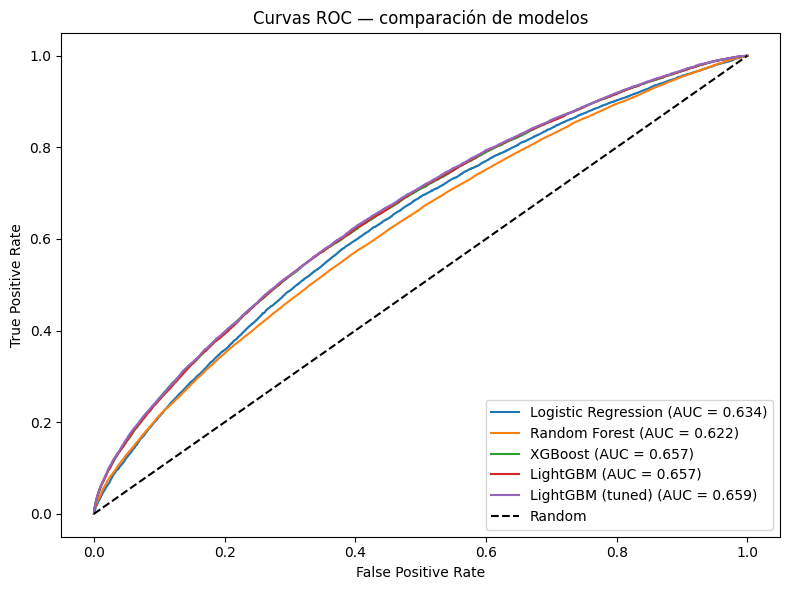

In [8]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/roc_curves_comparison.png", dpi=150)
plt.show()

## 8. Matriz de confusión del mejor modelo

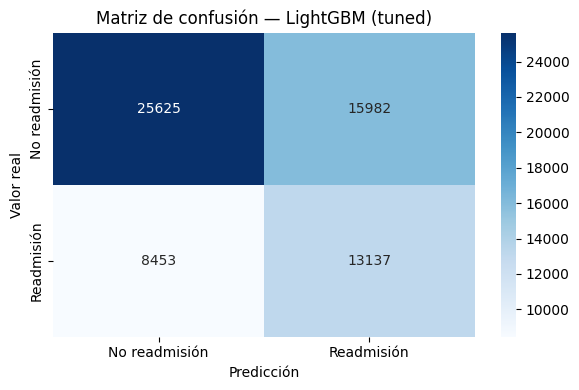


Classification Report:
               precision  recall  f1-score    support
No readmisión      0.752   0.616     0.677  41607.000
Readmisión         0.451   0.608     0.518  21590.000
accuracy           0.613   0.613     0.613      0.613
macro avg          0.602   0.612     0.598  63197.000
weighted avg       0.649   0.613     0.623  63197.000


In [9]:
plot_confusion_matrix(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/confusion_matrix_best.png"
)

print("\nClassification Report:")
print(get_classification_report(best_model, X_test, y_test).to_string())

## 10. Guardado de resultados

In [ ]:
import glob as _glob

# Añadir métricas del modelo tuneado a la tabla comparativa y guardar
tuned_row = pd.DataFrame([{**metrics_tuned, "Train time (s)": np.nan}], index=[best_model_name])
tuned_row = tuned_row.round(4)
results_full = pd.concat([results_df, tuned_row])
results_full.to_csv("../results/model_comparison.csv")

# Eliminar modelos anteriores para evitar que notebook 04 cargue un pkl equivocado
for old_path in _glob.glob("../models/*.pkl"):
    os.remove(old_path)

# Guardar el modelo tuneado
model_path = f"../models/{best_model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
joblib.dump(best_model, model_path)

print(f"Métricas guardadas en results/model_comparison.csv")
print(f"Mejor modelo guardado en {model_path}")
print(f"\nTabla final:")
results_full[["Accuracy", "Recall", "F1-score", "ROC-AUC", "Avg Precision"]]

## 11. Conclusiones

LightGBM es el modelo seleccionado con un ROC-AUC de 0.6589 tras la optimización de hiperparámetros.

Un AUC en el rango 0.65–0.67 es coherente con lo que reporta la literatura para predicción de reingreso a 30 días con datos administrativos — estudios como Donzé et al. (2013) o el índice LACE+ obtienen valores similares (0.63–0.72) con fuentes comparables a MIMIC-IV. El techo de rendimiento está limitado por los propios datos: los registros administrativos no recogen factores como el entorno socioeconómico, la adherencia al tratamiento o los cuidados post-alta, que tienen un peso importante en el reingreso real.

La búsqueda de hiperparámetros aportó una mejora modesta (+0.002 AUC), lo esperado dado que LightGBM ya funciona bien con sus valores por defecto en datasets de este tamaño.

El análisis en profundidad — calibración, SHAP e interpretabilidad clínica — se realiza en `04_evaluation.ipynb`.